In [15]:
import pickle 
import pandas as pd
import numpy as np 

%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
path = '../attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4_corrs.pkl'

with open(path, 'rb') as f:
    corrs  = pickle.load(f)

In [29]:
corrs.keys()

dict_keys(['fg_corr_results', 'bg_corr_results'])

In [33]:


fg_corr_results = corrs['fg_corr_results']

bg_corr_results = corrs['bg_corr_results']


# put into df for easy plotting:

dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                 'bg_corrs':bg_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)

In [34]:
corr_results = pd.concat(dfs)


In [80]:

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [82]:

results['Stream'].replace('fg_corrs','target',inplace=True)
results['Stream'].replace('bg_corrs','distractor',inplace=True)


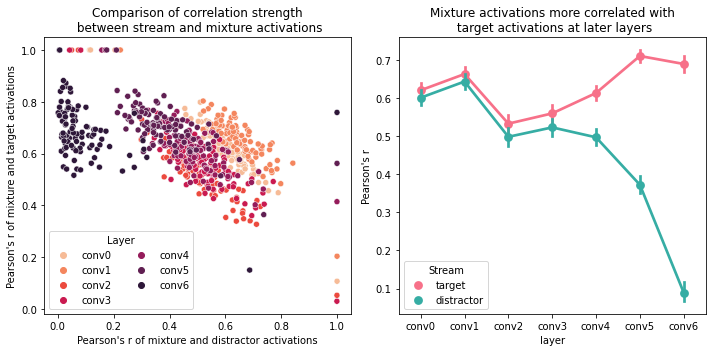

In [84]:
fig, axs = plt.subplots(1,2, figsize=(10,5))



sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs',
                hue='layer', palette='rocket_r', ax=axs[0])

sns.pointplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[1],
             ci=95, n_boot=10000, seed=1)

axs[0].set_title("Comparison of correlation strength\n between stream and mixture activations")
axs[0].set_xlabel("Pearson's r of mixture and distractor activations")
axs[0].set_ylabel("Pearson's r of mixture and target activations")
axs[0].legend(title='Layer', ncol=2, frameon=True)

axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")

plt.tight_layout()